In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
df = pd.read_csv("Cor_data.csv")

y = df["Cath"].map({
    "Cad": 1,
    "Normal": 0
})

X = df.drop(columns=["Cath"])

In [3]:
binary_cols = []

for col in X.columns:
    values = set(X[col].dropna().unique())

    if values.issubset({0, 1}):
        binary_cols.append(col)

In [4]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

continuous_cols = [
    col for col in numerical_cols
    if col not in binary_cols
    and X[col].nunique() > 5
]

In [5]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [7]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, continuous_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

In [9]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

In [10]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", log_reg)
    ]
)

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [13]:
results = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        results["test_accuracy"].mean(),
        results["test_precision"].mean(),
        results["test_recall"].mean(),
        results["test_f1"].mean(),
        results["test_roc_auc"].mean()
    ],
    "Std": [
        results["test_accuracy"].std(),
        results["test_precision"].std(),
        results["test_recall"].std(),
        results["test_f1"].std(),
        results["test_roc_auc"].std()
    ]
})

summary

,Metric,Mean,Std
0,Accuracy,0.857760,0.053684
1,Precision,0.926510,0.029772
2,Sensitivity,0.869979,0.068618
3,F1,0.895947,0.040895
4,ROC-AUC,0.917890,0.038250


In [15]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", svm)
    ]
)

In [16]:
svm_results = cross_validate(
    svm_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [17]:
svm_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        svm_results["test_accuracy"].mean(),
        svm_results["test_precision"].mean(),
        svm_results["test_recall"].mean(),
        svm_results["test_f1"].mean(),
        svm_results["test_roc_auc"].mean()
    ],
    "Std": [
        svm_results["test_accuracy"].std(),
        svm_results["test_precision"].std(),
        svm_results["test_recall"].std(),
        svm_results["test_f1"].std(),
        svm_results["test_roc_auc"].std()
    ]
})

svm_summary

,Metric,Mean,Std
0,Accuracy,0.861202,0.049922
1,Precision,0.926244,0.026335
2,Sensitivity,0.874736,0.060224
3,F1,0.898869,0.038720
4,ROC-AUC,0.907180,0.047627


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ]
)

In [19]:
rf_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [20]:
rf_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        rf_results["test_accuracy"].mean(),
        rf_results["test_precision"].mean(),
        rf_results["test_recall"].mean(),
        rf_results["test_f1"].mean(),
        rf_results["test_roc_auc"].mean()
    ],
    "Std": [
        rf_results["test_accuracy"].std(),
        rf_results["test_precision"].std(),
        rf_results["test_recall"].std(),
        rf_results["test_f1"].std(),
        rf_results["test_roc_auc"].std()
    ]
})

rf_summary

,Metric,Mean,Std
0,Accuracy,0.848087,0.043765
1,Precision,0.856045,0.040126
2,Sensitivity,0.948837,0.047433
3,F1,0.898891,0.029310
4,ROC-AUC,0.910801,0.044946


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        results["test_accuracy"].mean(),
        svm_results["test_accuracy"].mean(),
        rf_results["test_accuracy"].mean()
    ],

    "Precision": [
        results["test_precision"].mean(),
        svm_results["test_precision"].mean(),
        rf_results["test_precision"].mean()
    ],

    "Sensitivity": [
        results["test_recall"].mean(),
        svm_results["test_recall"].mean(),
        rf_results["test_recall"].mean()
    ],

    "F1": [
        results["test_f1"].mean(),
        svm_results["test_f1"].mean(),
        rf_results["test_f1"].mean()
    ],

    "ROC_AUC": [
        results["test_roc_auc"].mean(),
        svm_results["test_roc_auc"].mean(),
        rf_results["test_roc_auc"].mean()
    ]
})

comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Sensitivity,F1,ROC_AUC
0,Logistic Regression,0.857760,0.926510,0.869979,0.895947,0.917890
2,Random Forest,0.848087,0.856045,0.948837,0.898891,0.910801
1,SVM,0.861202,0.926244,0.874736,0.898869,0.907180


In [22]:
from sklearn.metrics import confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fp)


def npv_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fn)

In [23]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "specificity": make_scorer(specificity_score),
    "npv": make_scorer(npv_score),
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [24]:
results = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "NPV",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Mean": [
        results["test_accuracy"].mean(),
        results["test_precision"].mean(),
        results["test_sensitivity"].mean(),
        results["test_specificity"].mean(),
        results["test_npv"].mean(),
        results["test_f1"].mean(),
        results["test_roc_auc"].mean(),
        results["test_pr_auc"].mean()
    ],

    "Std": [
        results["test_accuracy"].std(),
        results["test_precision"].std(),
        results["test_sensitivity"].std(),
        results["test_specificity"].std(),
        results["test_npv"].std(),
        results["test_f1"].std(),
        results["test_roc_auc"].std(),
        results["test_pr_auc"].std()
    ]
})

summary

,Metric,Mean,Std
0,Accuracy,0.857760,0.053684
1,Precision,0.926510,0.029772
2,Sensitivity,0.869979,0.068618
3,Specificity,0.827451,0.073552
4,NPV,0.735239,0.119220
5,F1,0.895947,0.040895
6,ROC-AUC,0.917890,0.038250
7,PR-AUC,0.964924,0.013865


In [26]:
svm_results = cross_validate(
    svm_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [27]:
rf_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        results["test_accuracy"].mean(),
        svm_results["test_accuracy"].mean(),
        rf_results["test_accuracy"].mean()
    ],

    "Precision": [
        results["test_precision"].mean(),
        svm_results["test_precision"].mean(),
        rf_results["test_precision"].mean()
    ],

    "Sensitivity": [
        results["test_sensitivity"].mean(),
        svm_results["test_sensitivity"].mean(),
        rf_results["test_sensitivity"].mean()
    ],

    "Specificity": [
        results["test_specificity"].mean(),
        svm_results["test_specificity"].mean(),
        rf_results["test_specificity"].mean()
    ],

    "NPV": [
        results["test_npv"].mean(),
        svm_results["test_npv"].mean(),
        rf_results["test_npv"].mean()
    ],

    "F1": [
        results["test_f1"].mean(),
        svm_results["test_f1"].mean(),
        rf_results["test_f1"].mean()
    ],

    "ROC_AUC": [
        results["test_roc_auc"].mean(),
        svm_results["test_roc_auc"].mean(),
        rf_results["test_roc_auc"].mean()
    ],

    "PR_AUC": [
        results["test_pr_auc"].mean(),
        svm_results["test_pr_auc"].mean(),
        rf_results["test_pr_auc"].mean()
    ]
})

comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Sensitivity,Specificity,NPV,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.857760,0.926510,0.869979,0.827451,0.735239,0.895947,0.917890,0.964924
2,Random Forest,0.848087,0.856045,0.948837,0.600654,0.846275,0.898891,0.910801,0.954370
1,SVM,0.861202,0.926244,0.874736,0.828105,0.738421,0.898869,0.907180,0.954317


In [29]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [30]:

logistic_probs = cross_val_predict(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [31]:
svm_probs = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [32]:
rf_probs = cross_val_predict(
    rf_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [33]:
logistic_probs = cross_val_predict(
    logistic_pipeline, 
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:,1]

svm_probs = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

rf_probs = cross_val_predict(
    rf_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [34]:
fpr_log, tpr_log, _ = roc_curve(y, logistic_probs)
auc_log = roc_auc_score(y, logistic_probs)

fpr_svm, tpr_svm, _ = roc_curve(y, svm_probs)
auc_svm = roc_auc_score(y, svm_probs)

fpr_rf, tpr_rf, _ = roc_curve(y, rf_probs)
auc_rf = roc_auc_score(y, rf_probs)

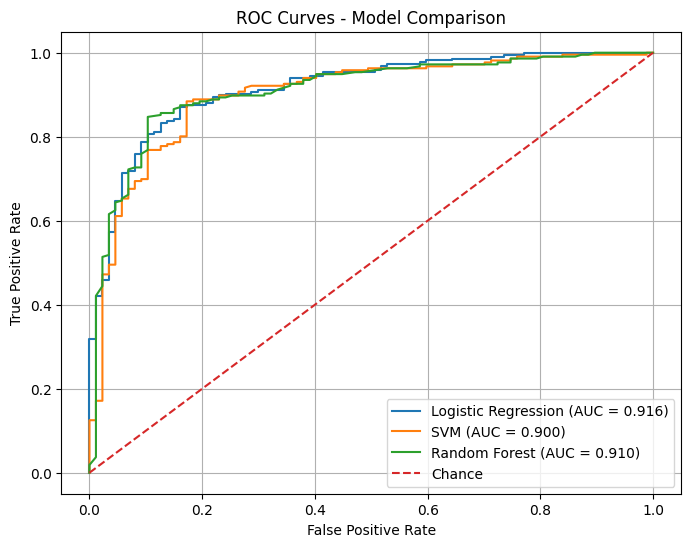

In [35]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {auc_svm:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", svm)
    ]
)

In [40]:
param_grid = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}

In [41]:
grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [42]:
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV ROC-AUC:")
print(grid.best_score_)

Best parameters:
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Best CV ROC-AUC:
0.9120673216432451


In [43]:
best_svm = grid.best_estimator_